In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from abstract_values.behavior.data import (
    FMRISubject,
    get_all_fmri_subjects,
    get_all_fmri_subject_ids,
    get_all_fmri_behavioral_data,
)

In [20]:
df = get_all_fmri_behavioral_data()
df = df[df['event_type'] == 'feedback']

df['response'] = df['response'].astype(float)

In [21]:
df.groupby(['subject', 'mapping']).size()

subject  mapping    
1        cdf            184
         inverse_cdf    184
2        cdf            184
dtype: int64

In [22]:
df['response'].isnull().groupby(['subject', 'mapping']).agg(['sum', 'mean'])

sum      mean
subject mapping                   
1       cdf           10  0.054348
        inverse_cdf   16  0.086957
2       cdf            2  0.010870

In [23]:
# Count non-responses per subject (normalized)
non_responses = df[df['response'].isna()].groupby('subject').size() / df.groupby('subject').size()
print("Non-responses per subject:")
print(non_responses)

Non-responses per subject:
subject
1    0.070652
2    0.010870
dtype: float64


In [24]:
rows = []
for subject_id in get_all_fmri_subject_ids():
    s = FMRISubject(subject_id)
    try:
        d = s.get_behavioral_data().reset_index()
        d = d[d['event_type'] == 'feedback'].copy()
        d['response'] = pd.to_numeric(d['response'], errors='coerce')
        rows.append({
            'subject': subject_id,
            'n_rows': len(d),
            'n_response_nan': d['response'].isna().sum(),
            'mappings': sorted(d['mapping'].dropna().unique().tolist()),
            'runs_found': sorted(d['run'].dropna().unique().tolist()),
        })
    except Exception as e:
        rows.append({'subject': subject_id, 'error': str(e)})

pd.DataFrame(rows)

,subject,n_rows,n_response_nan,mappings,runs_found
0,1,368,26,"[cdf, inverse_cdf]","[1, 2, 3, 4, 5, 6, 7, 8]"
1,2,184,2,[cdf],"[1, 2, 3, 4, 5, 6, 7, 8]"


Text(0.5, 1.0, 'Subject 1: mean response by orientation')

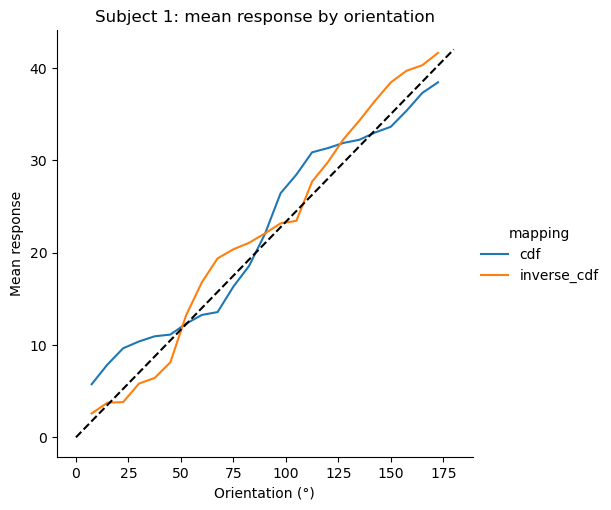

In [25]:
subject_id = 1
tmp = df.xs(subject_id, level='subject', drop_level=False).groupby(['subject', 'mapping', 'orientation'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line')
plt.plot([0, 180], [0, 42], 'k--')
g.set_axis_labels('Orientation (°)', 'Mean response')
plt.title(f'Subject {subject_id}: mean response by orientation')

Text(0.5, 1.0, 'All subjects: mean response by orientation')

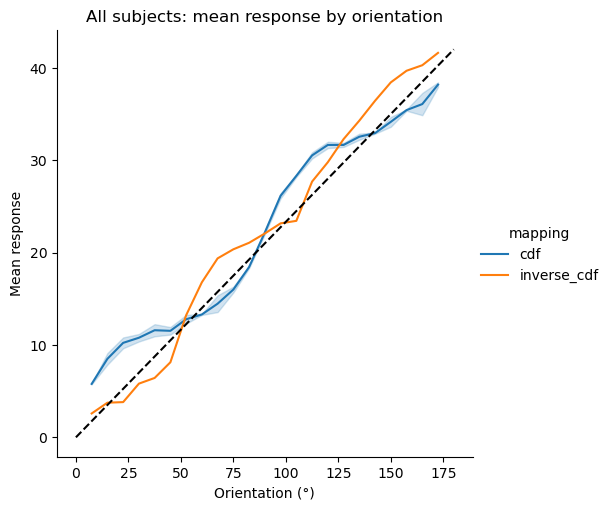

In [26]:
tmp = df.groupby(['subject', 'mapping', 'orientation'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='orientation', y='response', hue='mapping', kind='line')
plt.plot([0, 180], [0, 42], 'k--')
g.set_axis_labels('Orientation (°)', 'Mean response')
plt.title('All subjects: mean response by orientation')

Text(0.5, 1.0, 'All subjects: mean response by true value')

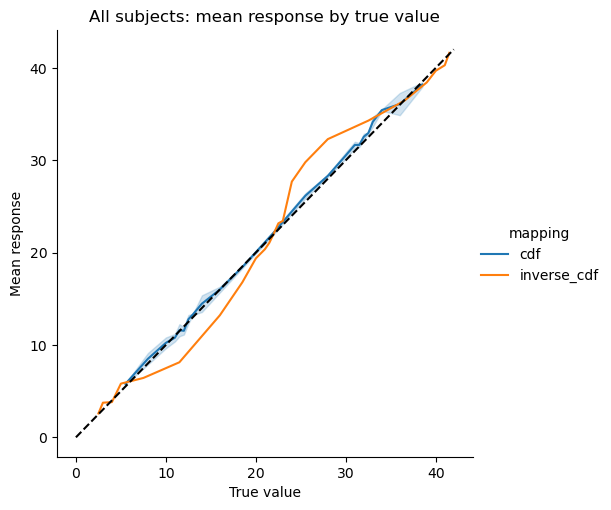

In [27]:
tmp = df.groupby(['subject', 'mapping', 'value'])['response'].mean()

g = sns.relplot(data=tmp.reset_index(), x='value', y='response', hue='mapping', kind='line')
plt.plot([0, 42], [0, 42], 'k--')
g.set_axis_labels('True value', 'Mean response')
plt.title('All subjects: mean response by true value')

Text(0.5, 1.0, 'Mean error by orientation (all subjects)')

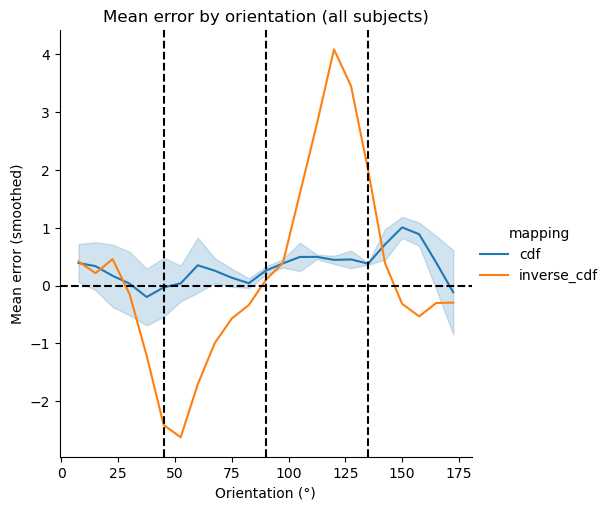

In [28]:
work = df.reset_index().copy()
work['error'] = work['response'] - work['value']

tmp = (
    work.groupby(['subject', 'mapping', 'orientation'], as_index=False)['error']
        .mean()
        .sort_values(['subject', 'mapping', 'orientation'])
)

tmp['error_smooth'] = (
    tmp.groupby(['subject', 'mapping'])['error']
       .transform(lambda s: s.rolling(3, center=True, min_periods=1).mean())
)

g = sns.relplot(data=tmp, x='orientation', y='error_smooth', hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Orientation (°)', 'Mean error (smoothed)')
plt.axhline(0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    plt.axvline(ori, color='k', linestyle='--')
plt.title('Mean error by orientation (all subjects)')

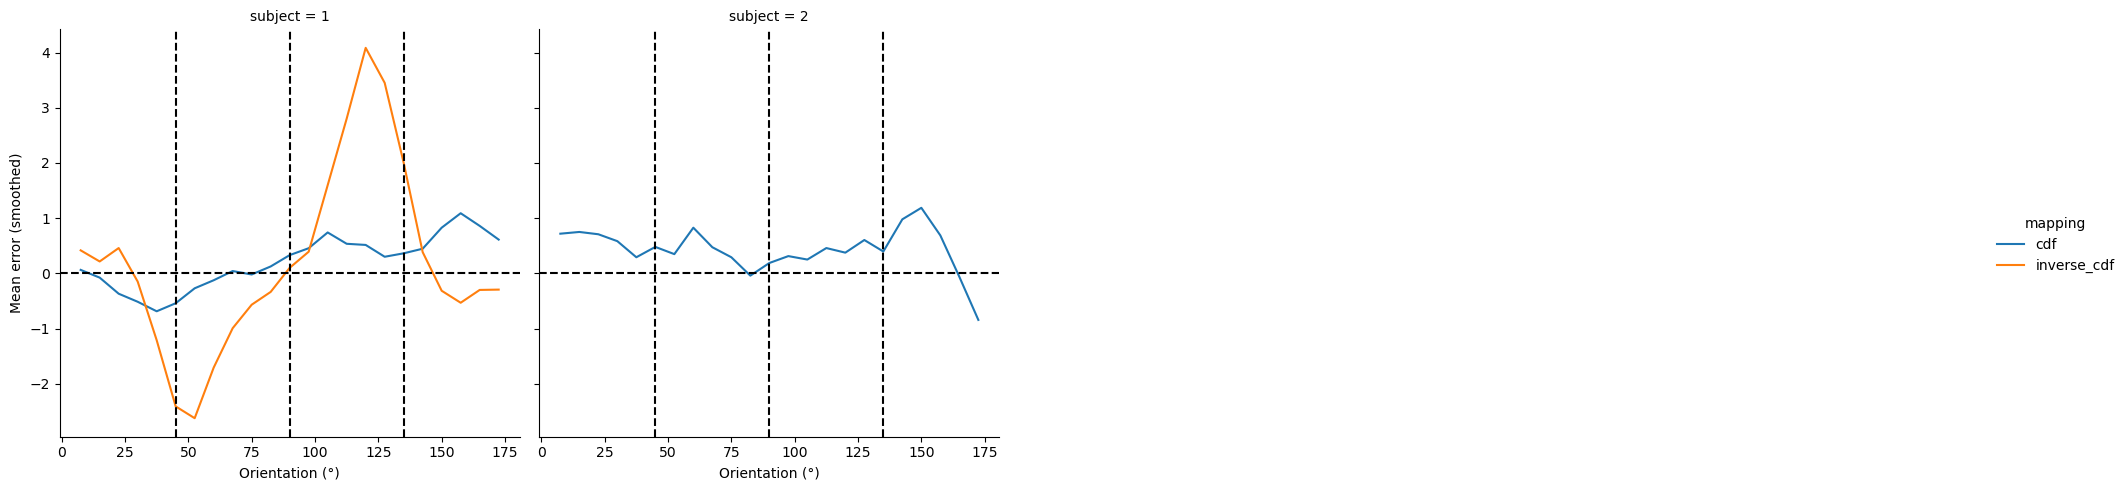

In [29]:
g = sns.relplot(data=tmp, x='orientation', y='error_smooth', hue='mapping', kind='line', errorbar='se',
                col='subject', col_wrap=4)
g.map(plt.axhline, y=0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    g.map(plt.axvline, x=ori, color='k', linestyle='--')
g.set_axis_labels('Orientation (°)', 'Mean error (smoothed)')

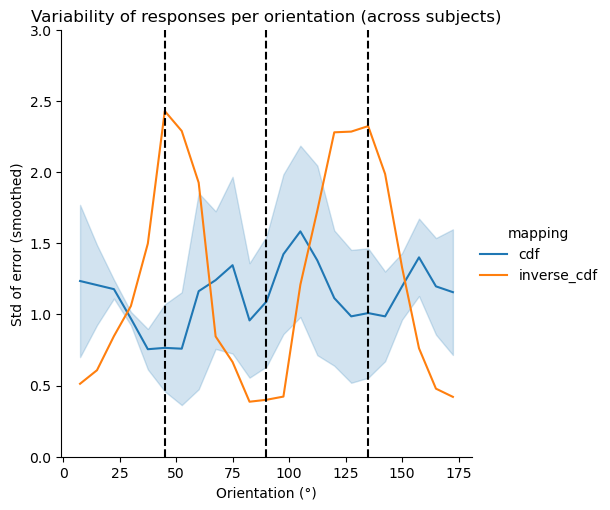

In [30]:
# Standard deviation of error per subject/mapping/orientation, smoothed over orientations
std_tmp = (
    work.groupby(['subject', 'mapping', 'orientation'], as_index=False)['error']
        .std()
        .rename(columns={'error': 'error_std'})
        .sort_values(['subject', 'mapping', 'orientation'])
)

std_tmp['error_std_smooth'] = (
    std_tmp.groupby(['subject', 'mapping'])['error_std']
           .transform(lambda s: s.rolling(3, center=True, min_periods=1).mean())
)

g = sns.relplot(data=std_tmp, x='orientation', y='error_std_smooth',
                hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Orientation (°)', 'Std of error (smoothed)')
plt.title('Variability of responses per orientation (across subjects)')

for ori in [45, 90, 135]:
    plt.axvline(ori, color='k', linestyle='--')

g.set(ylim=(0, 3))

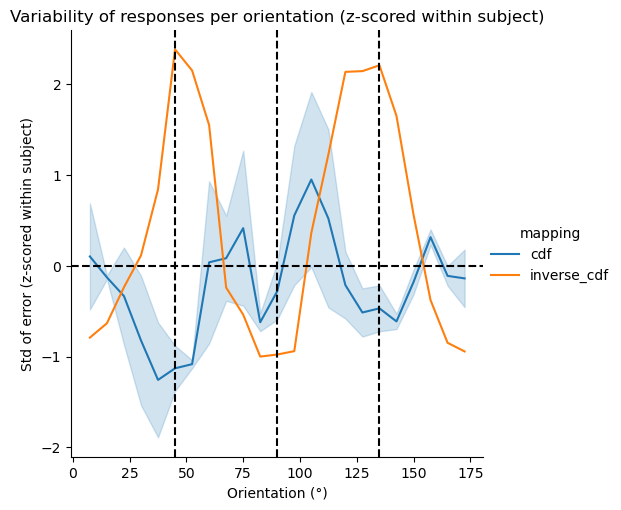

In [31]:
# Z-score error_std_smooth within each subject
std_tmp['error_std_z'] = (
    std_tmp.groupby('subject')['error_std_smooth']
           .transform(lambda s: (s - s.mean()) / s.std())
)

g = sns.relplot(data=std_tmp, x='orientation', y='error_std_z',
                hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Orientation (°)', 'Std of error (z-scored within subject)')
plt.title('Variability of responses per orientation (z-scored within subject)')
plt.axhline(0, color='k', linestyle='--')
for ori in [45, 90, 135]:
    plt.axvline(ori, color='k', linestyle='--')

Text(0.5, 1.0, 'Response time by run')

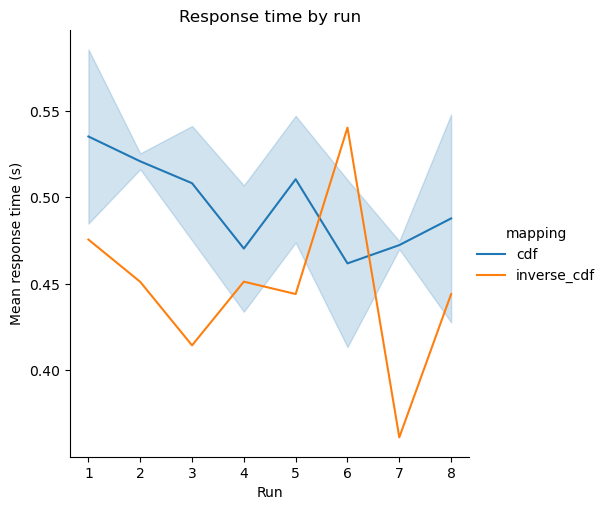

In [32]:
# Response time across runs (check for fatigue / learning effects)
work['response_time'] = pd.to_numeric(work['response_time'], errors='coerce')
rt_tmp = work.groupby(['subject', 'mapping', 'run'], as_index=False)['response_time'].mean()

g = sns.relplot(data=rt_tmp, x='run', y='response_time', hue='mapping', kind='line', errorbar='se')
g.set_axis_labels('Run', 'Mean response time (s)')
plt.title('Response time by run')

,mean,std
mapping,,
cdf,0.954828,0.456288
inverse_cdf,1.446429,NaN


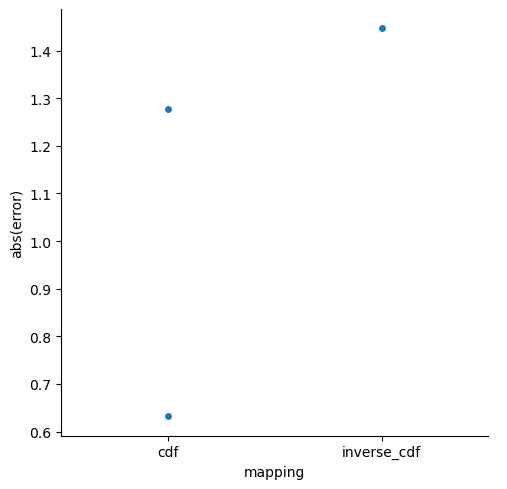

In [33]:
df['error'] = df['response'] - df['value']
df['abs(error)'] = df['error'].abs()
tmp = df.groupby(['subject', 'mapping'])['abs(error)'].mean()

sns.catplot(data=tmp.to_frame("abs(error)"), x='mapping', y='abs(error)', kind='swarm')

tmp.groupby('mapping').agg(['mean', 'std'])